In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial

# Однородность

1. Рассмотрим t-критерий и критерий Манна-Уитни: применим их для сравнения однородности двух
выборок из распределения из а) N (0, 1) распределения и N (μ, 1) распределения, б) распределения Laplace(0, 1) и Laplace(μ, 2) распределения, взяв размеры выборок равные а) 10, б) 50, в) 100. Используйте разные виды критериев, меняя настройки: для t-критерия equal_var и permutations, для Манна-Уитни – exact и asymptotic method. Построить график мощности всех версий критериев в зависимости от μ.

In [ ]:
crits = [[stats.ttest_ind, 'T-test classic'],
         [partial(stats.ttest_ind, equal_var =False), "T-test Welch's"],
         [partial(stats.ttest_ind, method = stats.PermutationMethod(n_resamples=1000)), "T-test permutation"],
         [partial(stats.ttest_ind, equal_var = False, method = stats.PermutationMethod(n_resamples=1000)), "T-test all in"],
         [partial(stats.mannwhitneyu, method = 'asymptotic'), "Mann-Whitney Asymptotic"],
         [partial(stats.mannwhitneyu, method = 'exact'), "Mann-Whitney Exact"]]


def criterion_id(pval_gen, data_gen1, data_gen2, label_custom = None, output = True, ad = False, k = 100):
    p_val = []
    a = 0.05
    for _ in range(k):
        x_data = data_gen1()
        y_data = data_gen2()
        if ad:
            data = np.array([x_data, y_data])
            pval = pval_gen(data)[1]
        else:
            pval = pval_gen(x_data, y_data)[1]
        p_val.append(pval)
    ecdf = stats.ecdf(p_val)
    if output:
        sns.ecdfplot(p_val, label = f'{label_custom}: power = {ecdf.cdf.evaluate(a)}')
    return ecdf.cdf.evaluate(a)


def compare_crit(gen1, gen2, title = None):
    for crit in crits:
        pval_gen = crit[0]
        label = crit[1]
        ad = False
        if label == "K-samp AD":
            ad = True
        power = criterion_id(pval_gen, gen1, gen2, label_custom = label, ad = ad)
    
    x = np.linspace(0,1,1000)
    plt.plot(x,x,linestyle = '--', color='black')
    plt.title(title)
    plt.legend()
    plt.show()


def compare_power(gen1, gen2, vals, title = None):
    for crit in crits:
        pval_gen = crit[0]
        crit_name = crit[1]
        ad = False
        if crit_name in ["K-samp AD", "Chi2"]:
            ad = True
        power_mass = []
        for param in vals:
            power = criterion_id(pval_gen, gen1, partial(gen2, param), output= False, ad = ad)
            power_mass.append(power)
        plt.plot(vals, power_mass, marker='o', label = crit_name)
    plt.legend()
    plt.title(title)

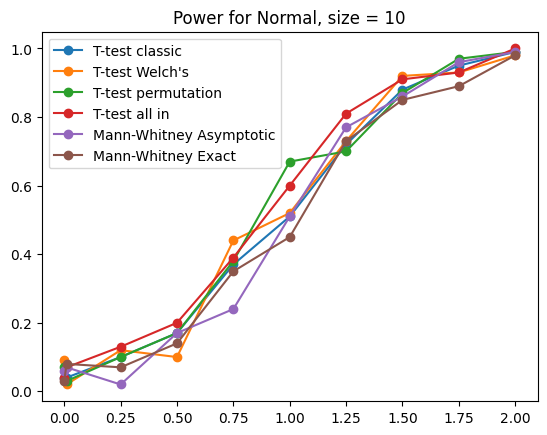

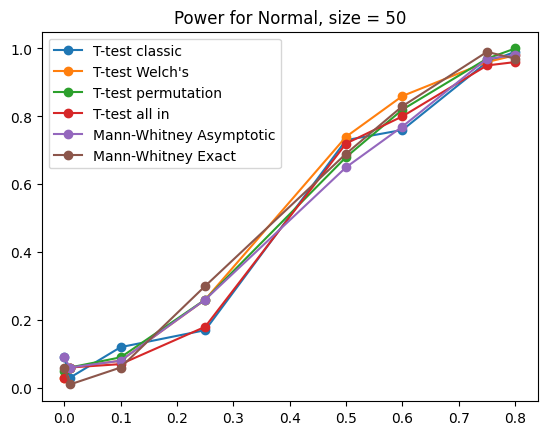

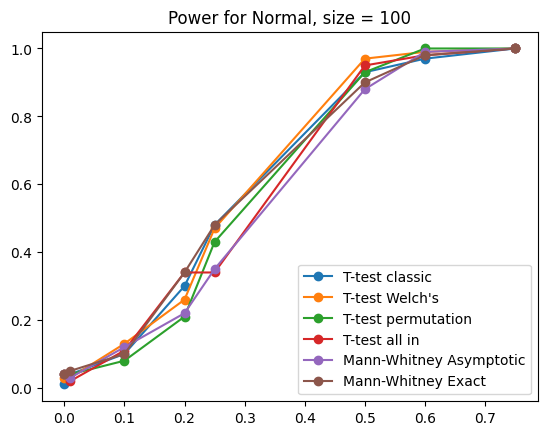

In [ ]:
crits = [[stats.ttest_ind, 'T-test classic'],
         [partial(stats.ttest_ind, equal_var =False), "T-test Welch's"],
         [partial(stats.ttest_ind, method = stats.PermutationMethod(n_resamples=1000)), "T-test permutation"],
         [partial(stats.ttest_ind, equal_var = False, method = stats.PermutationMethod(n_resamples=1000)), "T-test all in"],
         [partial(stats.mannwhitneyu, method = 'asymptotic'), "Mann-Whitney Asymptotic"],
         [partial(stats.mannwhitneyu, method = 'exact'), "Mann-Whitney Exact"]]


n = 10
mu_vals_extended = [0,0.01,0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]  
compare_power(partial(stats.norm.rvs,size = n), partial(stats.norm.rvs, size = n), mu_vals_extended, title = f'Power for Normal, size = {n}')
plt.show()

n = 50
mu_vals_extended = [0, 0.01, 0.1, 0.25, 0.5, 0.6, 0.75, 0.8]  
compare_power(partial(stats.norm.rvs,size = n), partial(stats.norm.rvs, size = n), mu_vals_extended, title = f'Power for Normal, size = {n}')
plt.show()

n = 100
mu_vals_extended = [0, 0.01, 0.1, 0.2, 0.25, 0.5, 0.6, 0.75]  
compare_power(partial(stats.norm.rvs,size = n), partial(stats.norm.rvs, size = n), mu_vals_extended, title = f'Power for Normal, size = {n}')
plt.show()

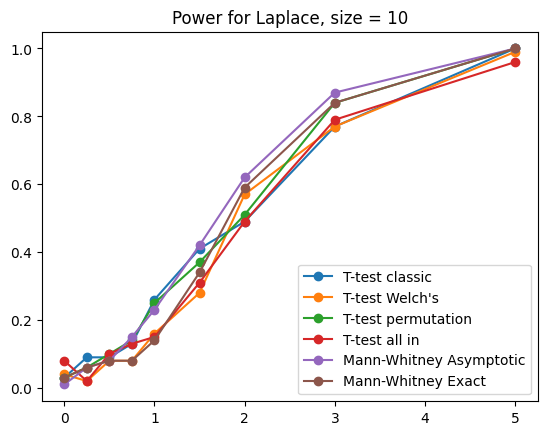

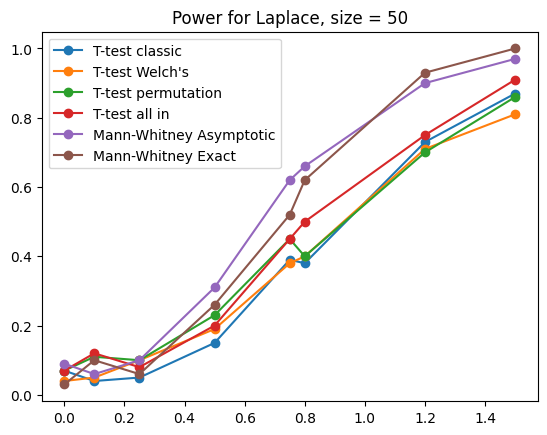

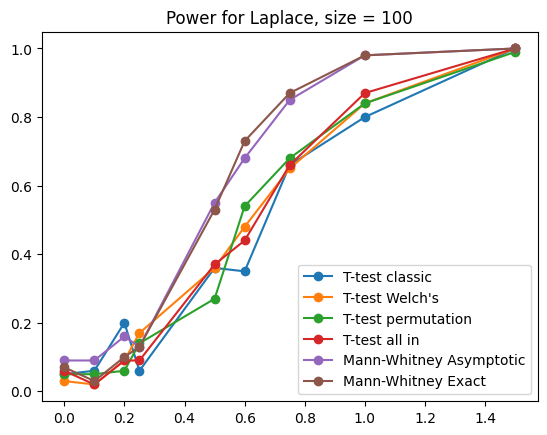

In [ ]:
crits = [[stats.ttest_ind, 'T-test classic'],
         [partial(stats.ttest_ind, equal_var =False), "T-test Welch's"],
         [partial(stats.ttest_ind, method = stats.PermutationMethod(n_resamples=1000)), "T-test permutation"],
         [partial(stats.ttest_ind, equal_var = False, method = stats.PermutationMethod(n_resamples=1000)), "T-test all in"],
         [partial(stats.mannwhitneyu, method = 'asymptotic'), "Mann-Whitney Asymptotic"],
         [partial(stats.mannwhitneyu, method = 'exact'), "Mann-Whitney Exact"]]


n = 10
mu_vals_extended = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 5]  
compare_power(partial(stats.laplace.rvs,size = n), partial(stats.laplace.rvs,scale = 2, size = n), mu_vals_extended, title = f'Power for Laplace, size = {n}')
plt.show()

n = 50
mu_vals_extended = [0, 0.1, 0.25, 0.5, 0.75, 0.8, 1.2, 1.5]  
compare_power(partial(stats.laplace.rvs,size = n), partial(stats.laplace.rvs, scale= 2, size = n), mu_vals_extended, title = f'Power for Laplace, size = {n}')
plt.show()

n = 100
mu_vals_extended = [0, 0.1, 0.2, 0.25, 0.5, 0.6, 0.75, 1 , 1.5]  
compare_power(partial(stats.laplace.rvs,size = n), partial(stats.laplace.rvs, scale = 2, size = n), mu_vals_extended, title = f'Power for Laplace, size = {n}')
plt.show()

2. Реализовать критерий Баумгартнера-Вейсса-Шиндлера в перестановочной версии. Проверить его работу на а) R[0, 1] и R[0, 1] выборках б) R[0, 1] и R[0.1, 1.1] выборках. Сравнить с встроенным критерием Стивенса-Шольца (scipy.stats.anderson_ksamp).

In [3]:
def bws_stat(x_data, y_data):
    n1 = len(x_data)
    n2 = len(y_data)

    z_data = np.concatenate((x_data, y_data))
    rank = stats.rankdata(z_data)

    R = np.sort(rank[:n1])
    S = np.sort(rank[n1:])

    i = np.arange(1, n1 + 1) 
    j = np.arange(1, n2 + 1)
    T1 = (1/(2*n1))*np.sum(((R[i - 1] - ((n1 + n2)*i)/n1)**2)/((i/(n1 + 1))*(1 - (i/(n1 + 1)))*(((n1 + n2)*n2)/n1)))
    T2 = (1/(2*n2))*np.sum(((S[j - 1] - ((n1 + n2)*j)/n2)**2)/((j/(n2 + 1))*(1 - (j/(n2 + 1)))*(((n1 + n2)*n1)/n2)))
    stat = T1 + T2
    return stat


def bws_permutate(x_data, y_data, N = 100):
    n1 = len(x_data)
    n2 = len(y_data)
    combined = np.concatenate((x_data, y_data))
    T = []
    for i in range(N):
        permuted = np.random.permutation(combined)
        x1 = permuted[:n1]
        y1 = permuted[n1:]
        T.append(bws_stat(x1,y1))

    return sorted(T)



def bws_crit(x_data, y_data):
    stat = bws_stat(x_data, y_data)
    T = bws_permutate(x_data, y_data)
    N = len(T)
    k = 0
    for i in range(N):
        if T[i] < stat:
            k+=1
        else:
            break
    pval = 1 - k/N
    return stat, pval

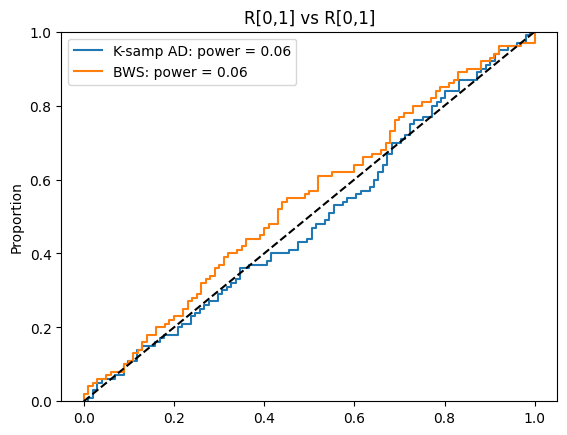

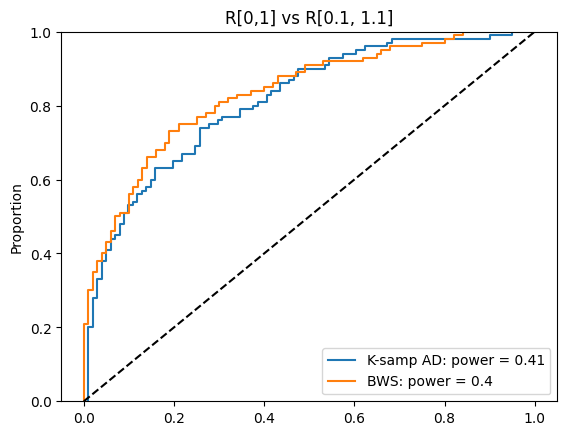

In [10]:
crits = [[partial(stats.anderson_ksamp, method = stats.PermutationMethod(n_resamples=100), variant = 'continuous'), "K-samp AD"],
         [bws_crit, "BWS"]]
n = 50
compare_crit(partial(stats.uniform.rvs, size = n),partial(stats.uniform.rvs, size = n), title = 'R[0,1] vs R[0,1]' )
compare_crit(partial(stats.uniform.rvs, size = n),partial(stats.uniform.rvs, loc = 0.1, size = n), title = 'R[0,1] vs R[0.1, 1.1]')


3. Сравнить (построив ЭФР p-value) критерии Манна - Уитни, критерий Смирнова (scipy.stats.ks_2samp),
критерий Стивенса-Шольца (scipy.stats.anderson_ksamp) и BWS на примере следующих модельных
данных:

(a) Xi, Yj ∼ N(0, 1),

(b) Xi ∼ N(0, 1), Yj ∼ N(0.3, 1),

(c) Xi ∼ N(0, 1), Yj ∼ N(0, 3/2),

(d) Xi ∼ N(0, 1), Yj ∼ tk, где tk – распределение Стьюдента с k степенями свободы,

(e) Xi ∼ N(0, 1), Yj – центрированная нормированная сумма k независимых с.в. из равномерного распределения R[−1, 1].

Размер выборки в каждом случае выбирать так, чтобы он был поменьше среди тех, когда часть крите-
риев замечает разницу.

In [11]:
crits = [[stats.mannwhitneyu, "Mann-Whitney"],
         [partial(stats.anderson_ksamp, method = stats.PermutationMethod(n_resamples=100), variant = 'continuous'), "K-samp AD"],
         [stats.ks_2samp, "Smirnov"],
         [bws_crit, "BWS"]]

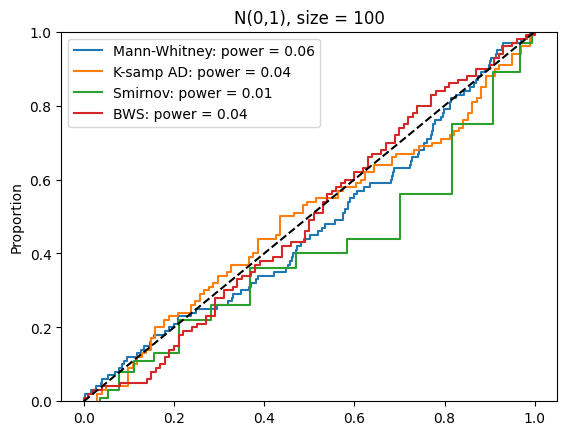

In [12]:
n = 100
compare_crit(partial(stats.norm.rvs, size = n), partial(stats.norm.rvs,size = n), title = f'N(0,1), size = {n}')

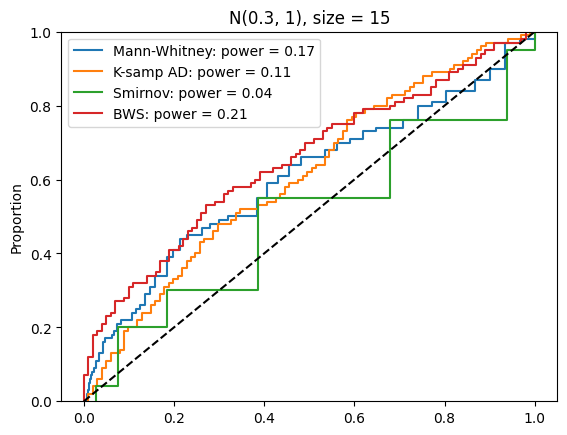

In [16]:
n = 15
compare_crit(partial(stats.norm.rvs, size = n), partial(stats.norm.rvs, loc = 0.3, size = n), title = f'N(0.3, 1), size = {n}')


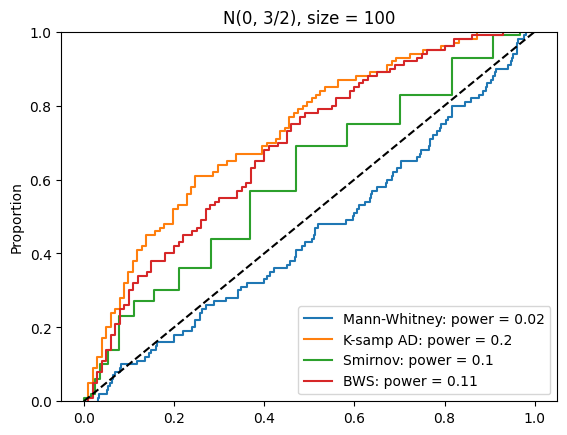

In [17]:
n = 100
compare_crit(partial(stats.norm.rvs, size = n), partial(stats.norm.rvs, scale = np.sqrt(1.5), size = n), title = f'N(0, 3/2), size = {n}')

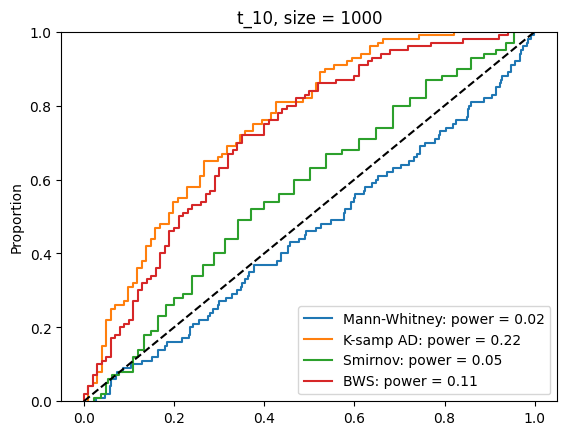

In [20]:
k = 10
n = 1000
compare_crit(partial(stats.norm.rvs, size = n), partial(stats.t.rvs, df = k, size = n), title =f't_{k}, size = {n}')

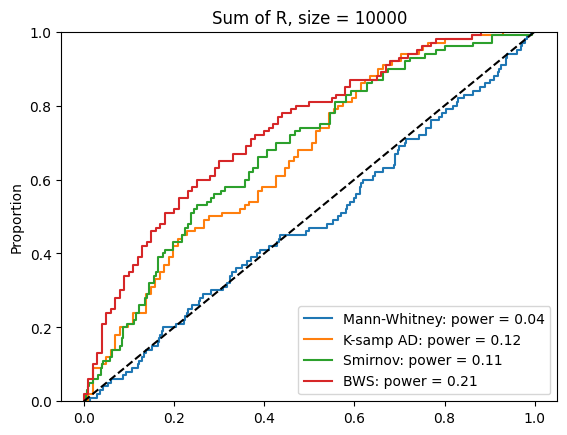

In [25]:
def gen_e(k, n):
    sigma2 = 1/3
    X = np.random.uniform(-1, 1, size=(n, k))
    S = np.sum(X, axis=1)
    normalized = S / np.sqrt(k * sigma2)
    return normalized


k = 5
n = 10000
compare_crit(partial(stats.norm.rvs,size = n), partial(gen_e, k =k, n = n), title = f'Sum of R, size = {n}')

4. * Проверить на однородность k выборок, используя критерии Стивенса-Шольца, хи-квадрат и Краскелла-Уоллиса:

(a) Xi,j ∼ N(0, 2 + i), i ≤ 4, j ≤ n;

(b) Xi,j ∼ N(i/4, 1), i ≤ 4, j ≤ n;

(c) Xi,j ∼ t3+i, i ≤ 4, j ≤ n, где t – распределение Стьюдента.

In [32]:
crits = [[partial(stats.anderson_ksamp, method = stats.PermutationMethod(n_resamples=100), variant = 'continuous'), "K-samp AD"],
         [stats.chi2_contingency, "Chi2"],
         [stats.kruskal, "Kruskal-Wallis"]]

In [38]:
def criterion_id_ksamp(pval_gen, data_gen, label_custom = None, output = True, ad = False, chi = False, k = 100):
    p_val = []
    a = 0.05
    for _ in range(k):
        samples = []
        for gen in data_gen:
            data = gen()
            samples.append(data)
        if ad:
            pval = pval_gen(samples)[1]
        elif chi:
            #chi2
            n = sum([len(i) for i in samples])
            combined = []
            for i in samples:
                combined = np.concatenate((combined, i))
            combined = np.sort(combined)
            k = int(np.log2(n))
            quantiles = [-np.inf]
            s = int(n/k)
            for i in range(1,k):
                quantiles.append((combined[i*s - 1] + combined[i*s])/2)
            quantiles.append(np.inf)
            observed = [np.histogram(i, quantiles)[0] for i in samples]
            pval = pval_gen(observed)[1]
        else:
            pval = pval_gen(*samples)[1]
        p_val.append(pval)
    ecdf = stats.ecdf(p_val)
    if output:
        sns.ecdfplot(p_val, label = f'{label_custom}: power = {ecdf.cdf.evaluate(a)}')
    return ecdf.cdf.evaluate(a)


def compare_crit_ksamp(data_gen, title = None):
    for crit in crits:
        pval_gen = crit[0]
        label = crit[1]
        ad = False
        chi = False
        if label =="K-samp AD":
            ad = True
        elif label == "Chi2":
            chi = True
        power = criterion_id_ksamp(pval_gen, data_gen, label_custom = label, ad = ad, chi = chi)
    
    x = np.linspace(0,1,1000)
    plt.plot(x,x,linestyle = '--', color='black')
    plt.title(title)
    plt.legend()
    plt.show()




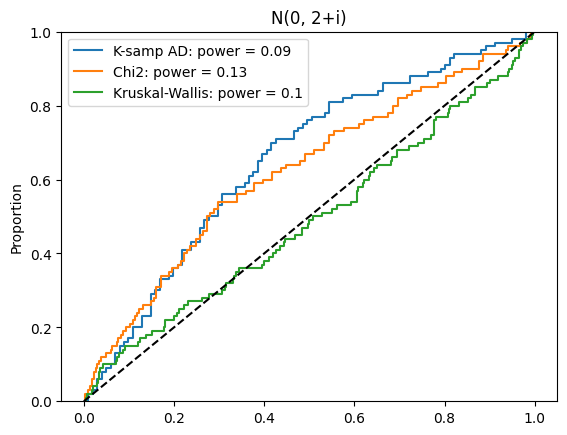

In [46]:
n = 15
data_gen_a = [partial(stats.norm.rvs, loc = 0, scale = np.sqrt(2 + i), size = n) for i in range(5)]
compare_crit_ksamp(data_gen_a, title = 'N(0, 2+i)')

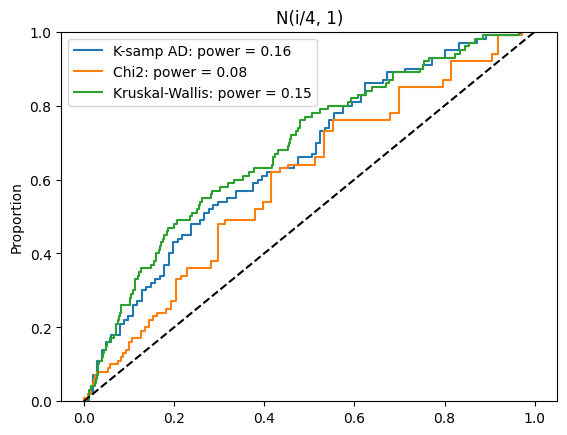

In [55]:
n = 5
data_gen_b = [partial(stats.norm.rvs, loc = i/4, size = n) for i in range(5)]
compare_crit_ksamp(data_gen_b, title="N(i/4, 1)")

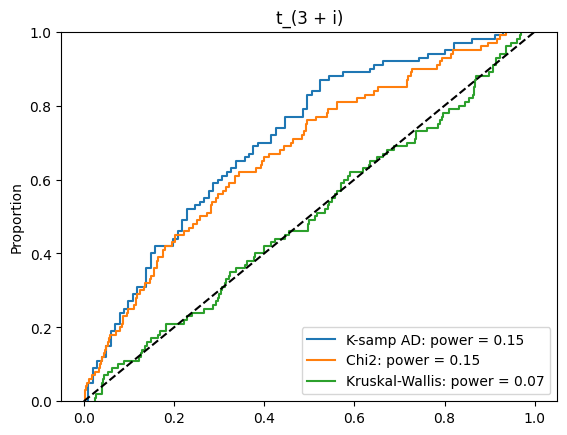

In [52]:
n = 500
data_gen_c = [partial(stats.t.rvs, df = 3+i, size = n) for i in range(5)]
compare_crit_ksamp(data_gen_c, title = 't_(3 + i)')